# Jegadeesh–Titman Momentum — 6M — Winner Drift

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('jt_academic', '6M', 'winner_drift')

## 1. Signal and portfolio rule

Raw price momentum ranks winners and losers. N denotes total names: N/2 winners long and N/2 losers short, normally ±1/N per name. The scheduled gross budgets are 50% each. This fixed-breadth, non-overlapping academic reference is not a replication of the paper's decile/cohort construction.

At scheduled rebalances, equal weight resets each leg's selected names. Winner drift retains relative position weights inside each leg, caps absolute weights at 2/N, and restores up to 50% gross per leg through scaling or equal residual allocation. Between scheduled dates both legs drift with prices. Borrowing is an academic 3%, 6% or 12% annual deduction on short notional; margin, recalls and stock-level borrow availability are not modeled.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Formation price return,MDTV (INR)
NSE:UFBL-EQ,287.2%,"42,078,240.59"
NSE:YASHO-EQ,216.2%,"37,220,195.50"
NSE:CUPID-EQ,187.6%,"2,261,224,535.95"
NSE:HFCL-EQ,182.6%,"3,688,024,397.99"
NSE:DIACABS-EQ,164.4%,"490,913,783.79"
NSE:CONFIPET-EQ,145.8%,"129,439,974.50"
NSE:CPPLUS-EQ,145.4%,"588,775,647.85"
NSE:AEROFLEX-EQ,144.4%,"644,982,030.67"
NSE:KSHINTL-EQ,142.6%,"194,129,104.07"
NSE:SETL-EQ,138.1%,"42,154,727.49"


Symbol,Leg,Actual weight,Current selection,Execution status,Formation price return,MDTV (INR)
NSE:UFBL-EQ,long,5.1%,True,selected,287.2%,"42,078,240.59"
NSE:YASHO-EQ,long,4.2%,True,selected,216.2%,"37,220,195.50"
NSE:CUPID-EQ,long,4.2%,True,selected,187.6%,"2,261,224,535.95"
NSE:HFCL-EQ,long,3.9%,True,selected,182.6%,"3,688,024,397.99"
NSE:DIACABS-EQ,long,4.2%,True,selected,164.4%,"490,913,783.79"
NSE:CONFIPET-EQ,long,4.2%,True,selected,145.8%,"129,439,974.50"
NSE:CPPLUS-EQ,long,3.8%,True,selected,145.4%,"588,775,647.85"
NSE:AEROFLEX-EQ,long,3.8%,True,selected,144.4%,"644,982,030.67"
NSE:KSHINTL-EQ,long,3.9%,True,selected,142.6%,"194,129,104.07"
NSE:SETL-EQ,long,4.2%,True,selected,138.1%,"42,154,727.49"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:UFBL-EQ,2026-01-30,181.20,2026-07-31,701.65,287.2%


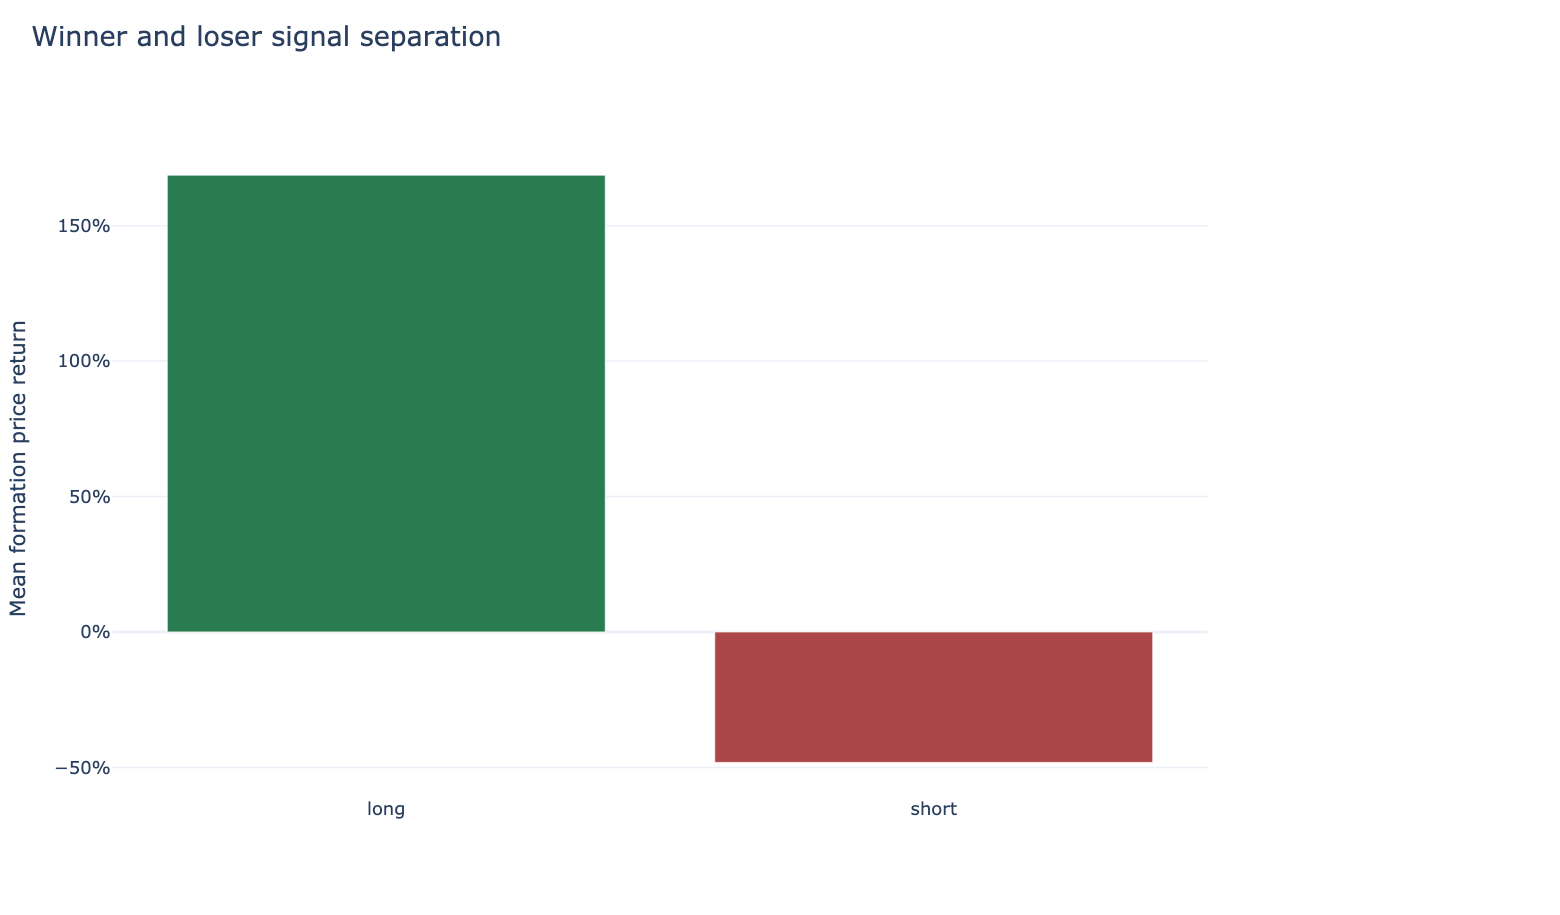

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Academic raw,Borrow 3%,Borrow 6%,Borrow 12%
1M,12,25.1%,21.9%,18.5%,10.8%
1M,24,30.3%,27.3%,24.3%,17.9%
1M,50,23.4%,20.8%,18.1%,12.7%
3M,12,25.9%,23.2%,20.3%,14.4%
3M,24,29.0%,26.4%,23.8%,18.4%
3M,50,22.2%,19.8%,17.4%,12.6%
6M,12,25.0%,22.9%,20.8%,16.4%
6M,24,28.1%,26.1%,24.0%,19.9%
6M,50,23.7%,21.7%,19.8%,15.8%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,18.5%,0.542,-77.5%,13.9%
1M,24,24.3%,0.959,-54.3%,9.7%
1M,50,18.1%,0.759,-50.6%,7.5%
3M,12,20.3%,0.630,-75.9%,11.5%
3M,24,23.8%,0.891,-69.9%,9.3%
3M,50,17.4%,0.663,-69.7%,7.1%
6M,12,20.8%,0.705,-43.8%,8.9%
6M,24,24.0%,1.106,-30.3%,5.9%
6M,50,19.8%,1.092,-33.6%,4.4%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,21.3%,92.3%,1581
1M,24,14.2%,89.8%,1580
1M,50,13.8%,87.9%,1580
3M,12,20.4%,92.1%,1617
3M,24,15.2%,87.9%,1067
3M,50,14.5%,88.8%,1031
6M,12,13.9%,90.6%,786
6M,24,9.4%,86.2%,669
6M,50,7.4%,84.4%,552


### CAGR

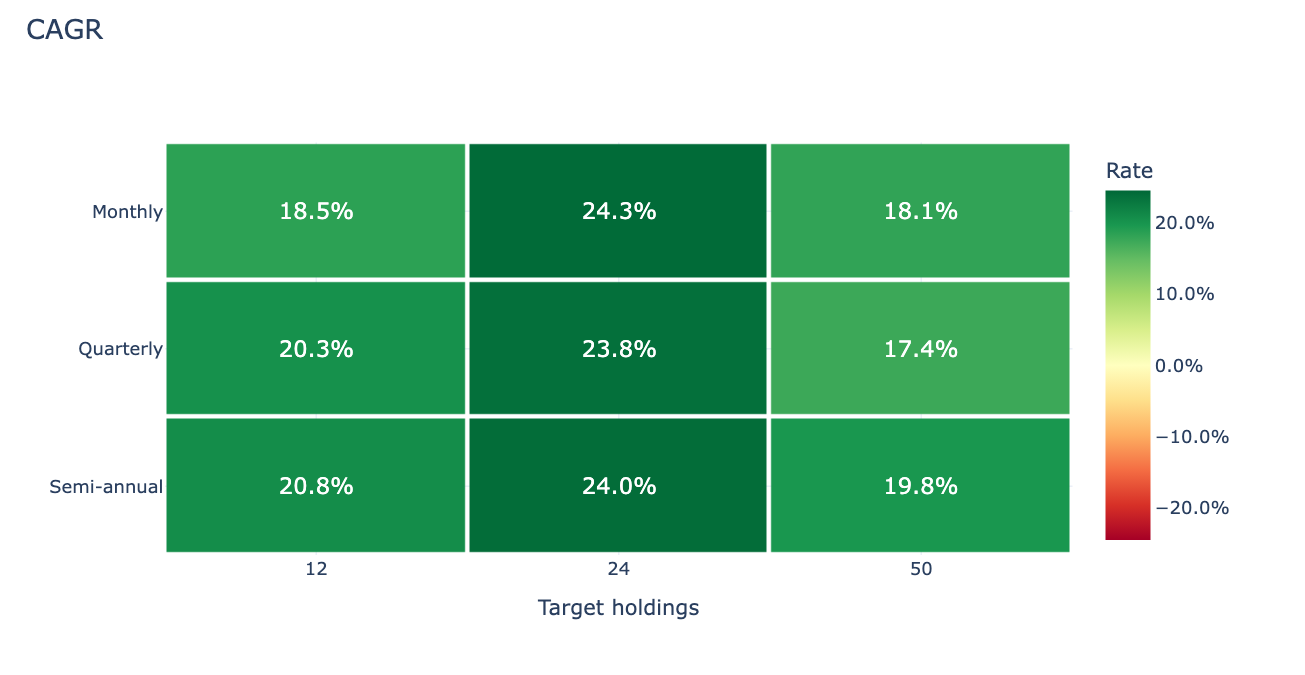

In [5]:
research.heatmap('cagr')

### Sharpe ratio

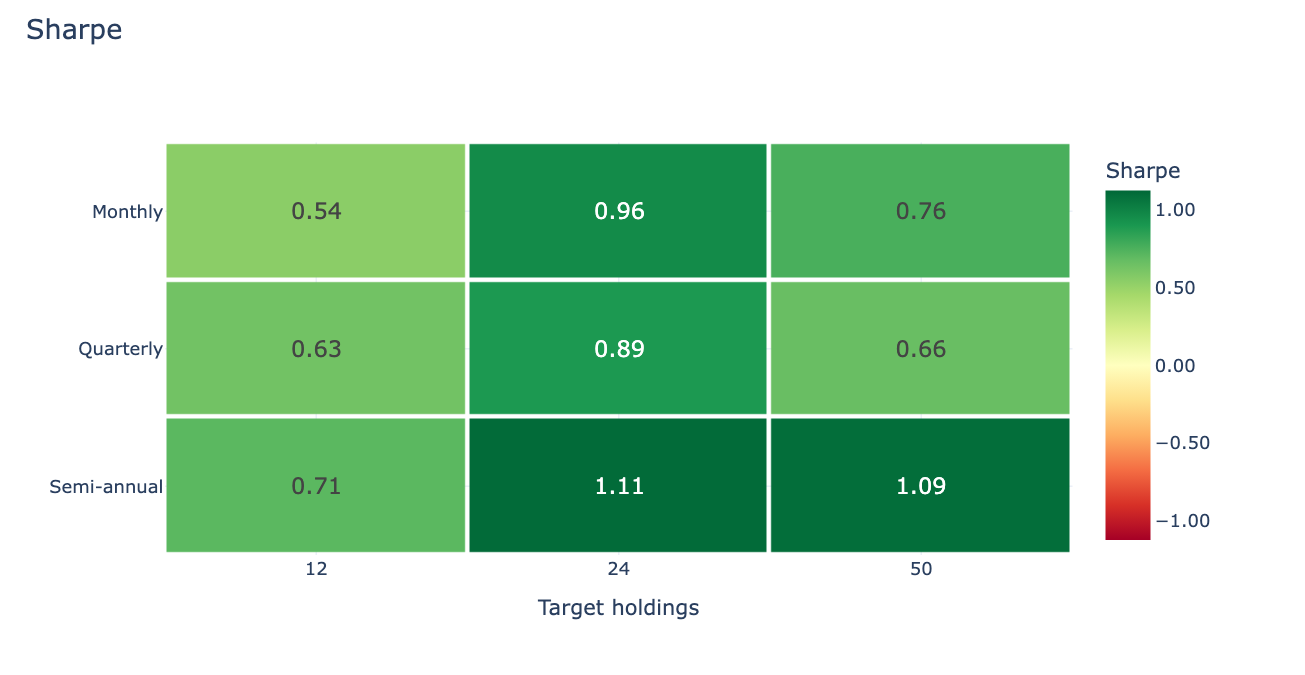

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

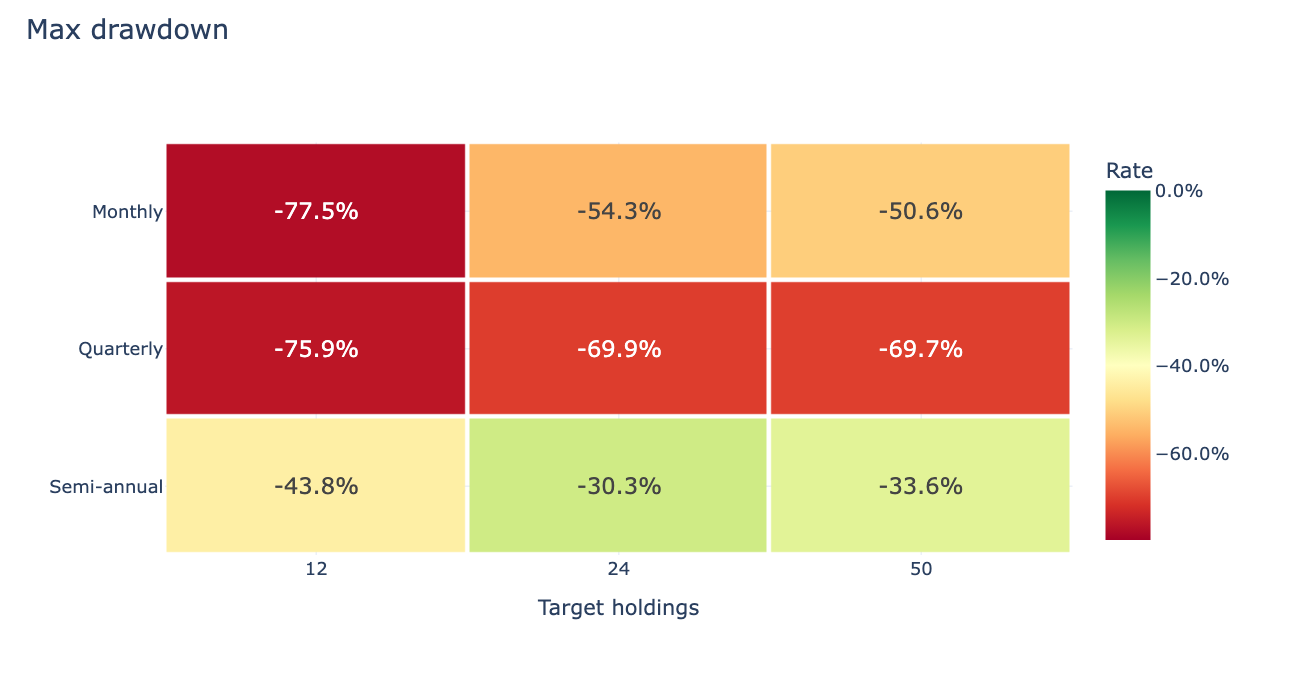

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

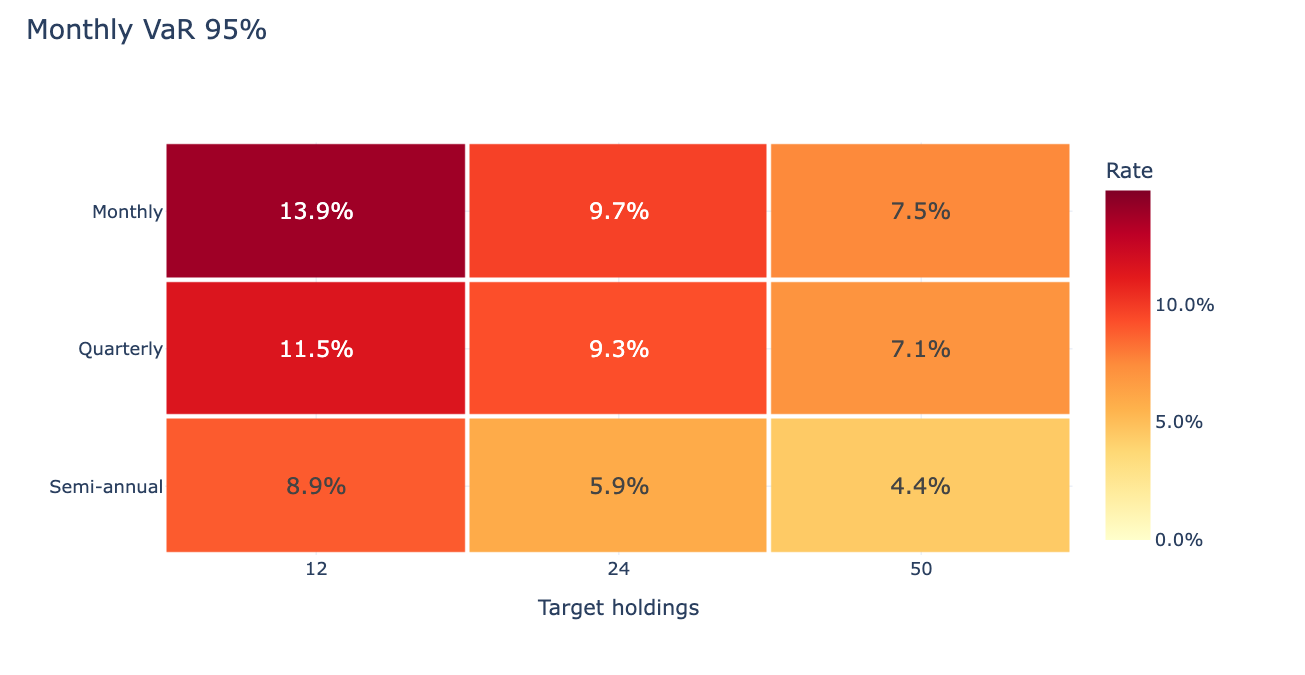

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

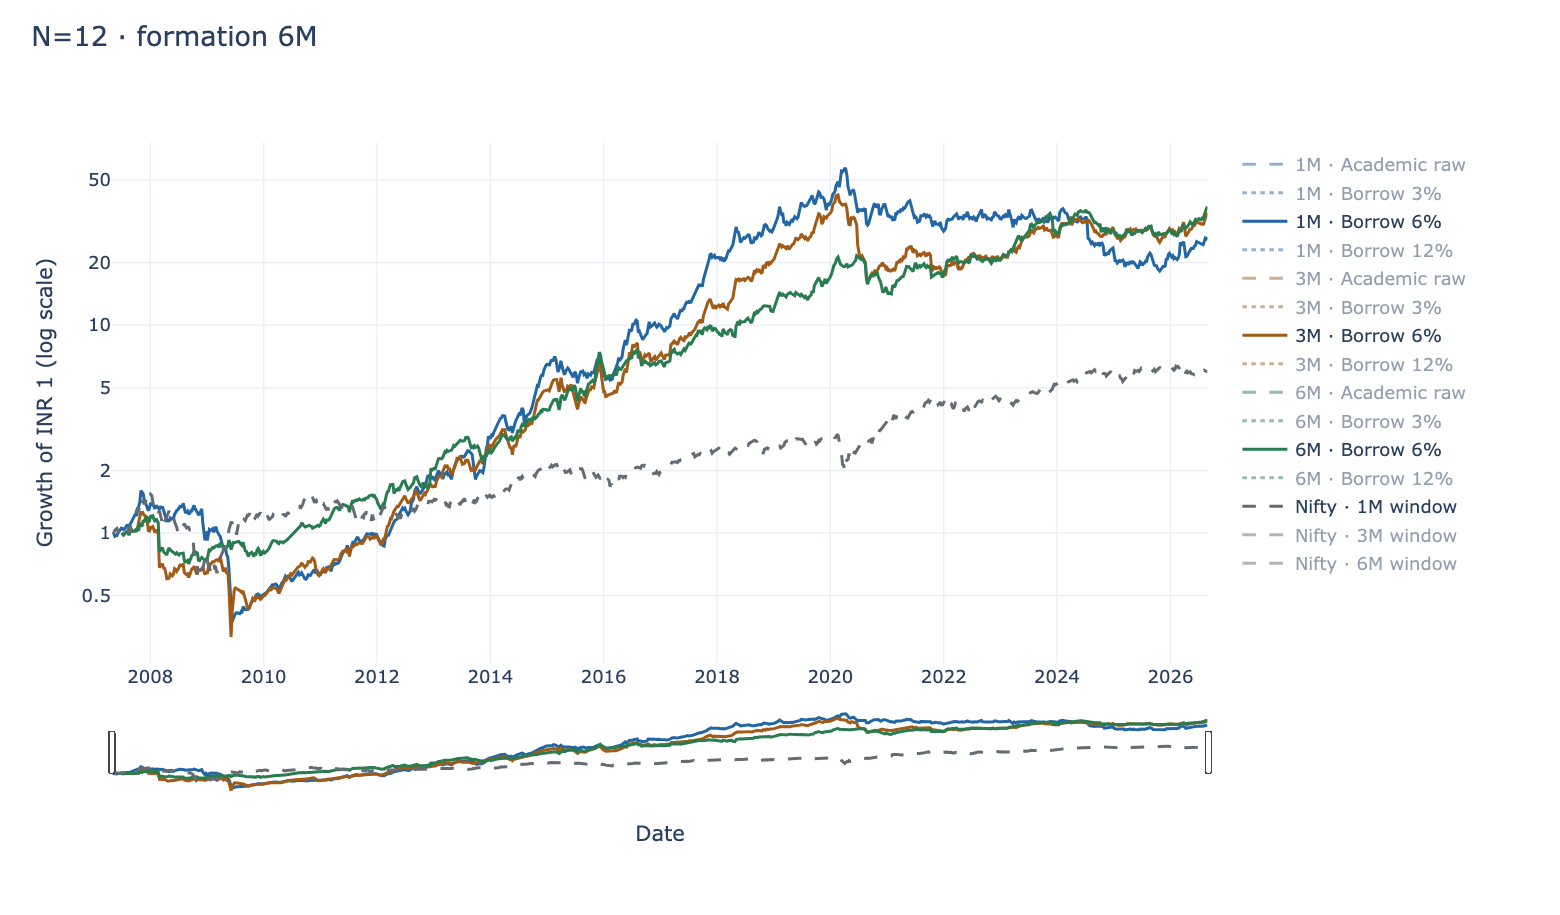

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,25.1%,0.778,-75.9%,12.6%
1M,Borrow 3%,21.9%,0.664,-76.7%,13.2%
1M,Borrow 6%,18.5%,0.542,-77.5%,13.9%
1M,Borrow 12%,10.8%,0.264,-84.1%,15.5%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,25.9%,0.836,-74.0%,11.0%
3M,Borrow 3%,23.2%,0.735,-75.0%,11.3%
3M,Borrow 6%,20.3%,0.630,-75.9%,11.5%
3M,Borrow 12%,14.4%,0.406,-77.7%,11.9%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,20.6%,91.4%,1581
1M,Borrow 3%,21.0%,91.8%,1581
1M,Borrow 6%,21.3%,92.3%,1581
1M,Borrow 12%,22.1%,93.5%,1581
3M,Academic raw,19.8%,90.4%,1077
3M,Borrow 3%,20.1%,91.5%,1616
3M,Borrow 6%,20.4%,92.1%,1617
3M,Borrow 12%,21.0%,93.1%,1617
6M,Academic raw,13.5%,88.8%,739
6M,Borrow 3%,13.7%,89.9%,779


In [9]:
research.equity(12)

### N=24

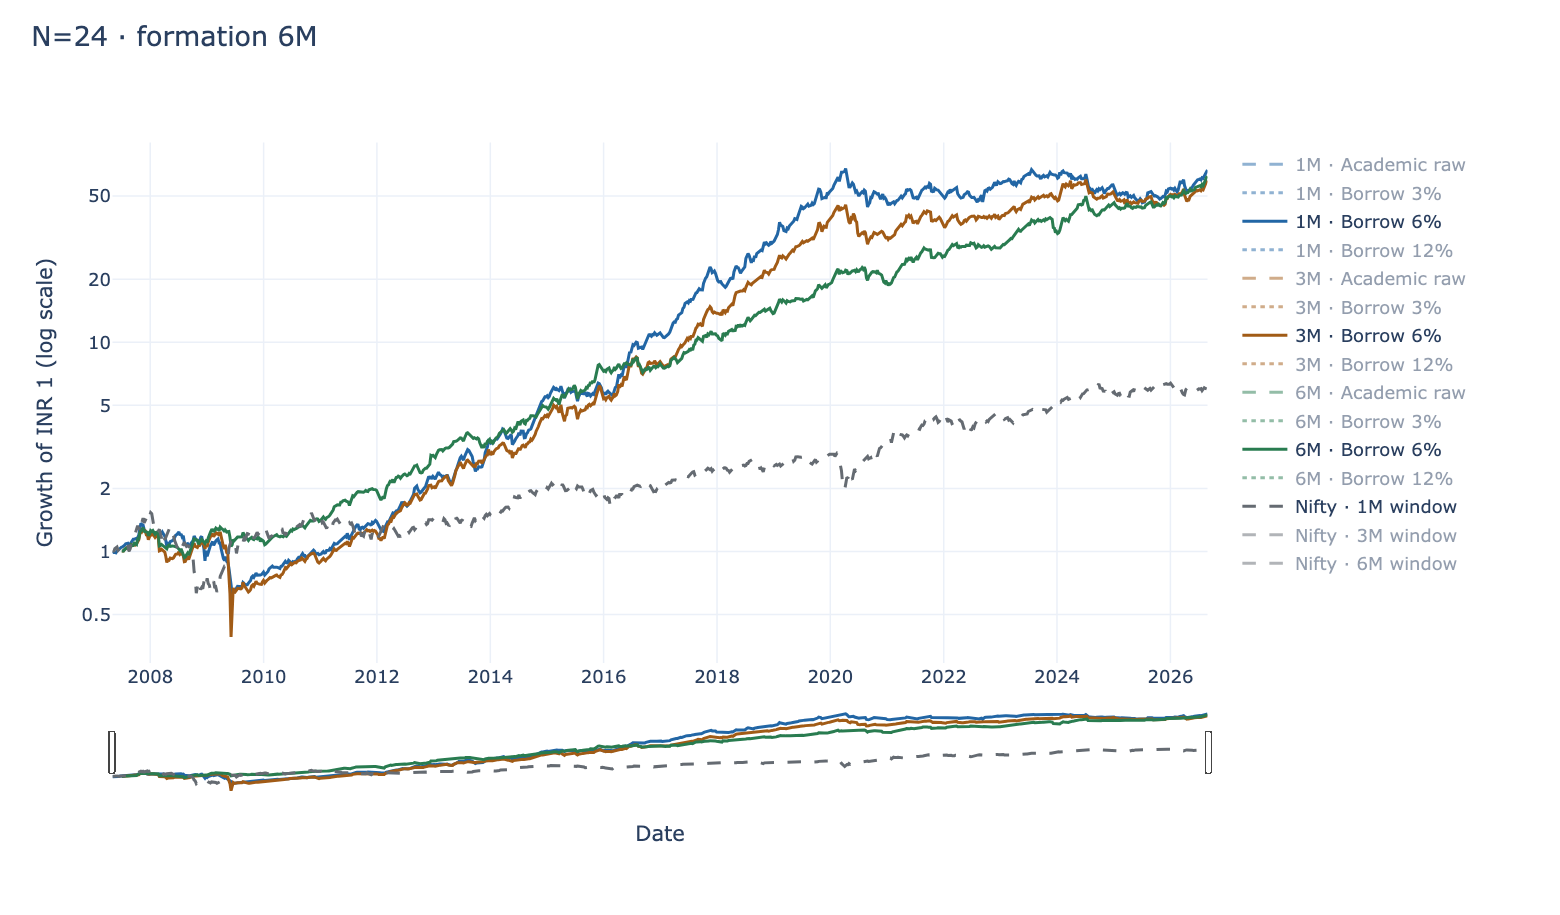

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,30.3%,1.248,-51.2%,9.4%
1M,Borrow 3%,27.3%,1.106,-52.8%,9.5%
1M,Borrow 6%,24.3%,0.959,-54.3%,9.7%
1M,Borrow 12%,17.9%,0.643,-57.3%,10.1%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,29.0%,1.131,-67.6%,8.8%
3M,Borrow 3%,26.4%,1.012,-68.7%,9.0%
3M,Borrow 6%,23.8%,0.891,-69.9%,9.3%
3M,Borrow 12%,18.4%,0.639,-72.3%,9.7%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,13.6%,86.7%,893
1M,Borrow 3%,13.9%,88.2%,927
1M,Borrow 6%,14.2%,89.8%,1580
1M,Borrow 12%,14.8%,91.1%,1580
3M,Academic raw,14.8%,85.4%,554
3M,Borrow 3%,15.0%,86.6%,932
3M,Borrow 6%,15.2%,87.9%,1067
3M,Borrow 12%,15.8%,90.1%,1130
6M,Academic raw,9.0%,84.0%,348
6M,Borrow 3%,9.2%,84.9%,348


In [10]:
research.equity(24)

### N=50

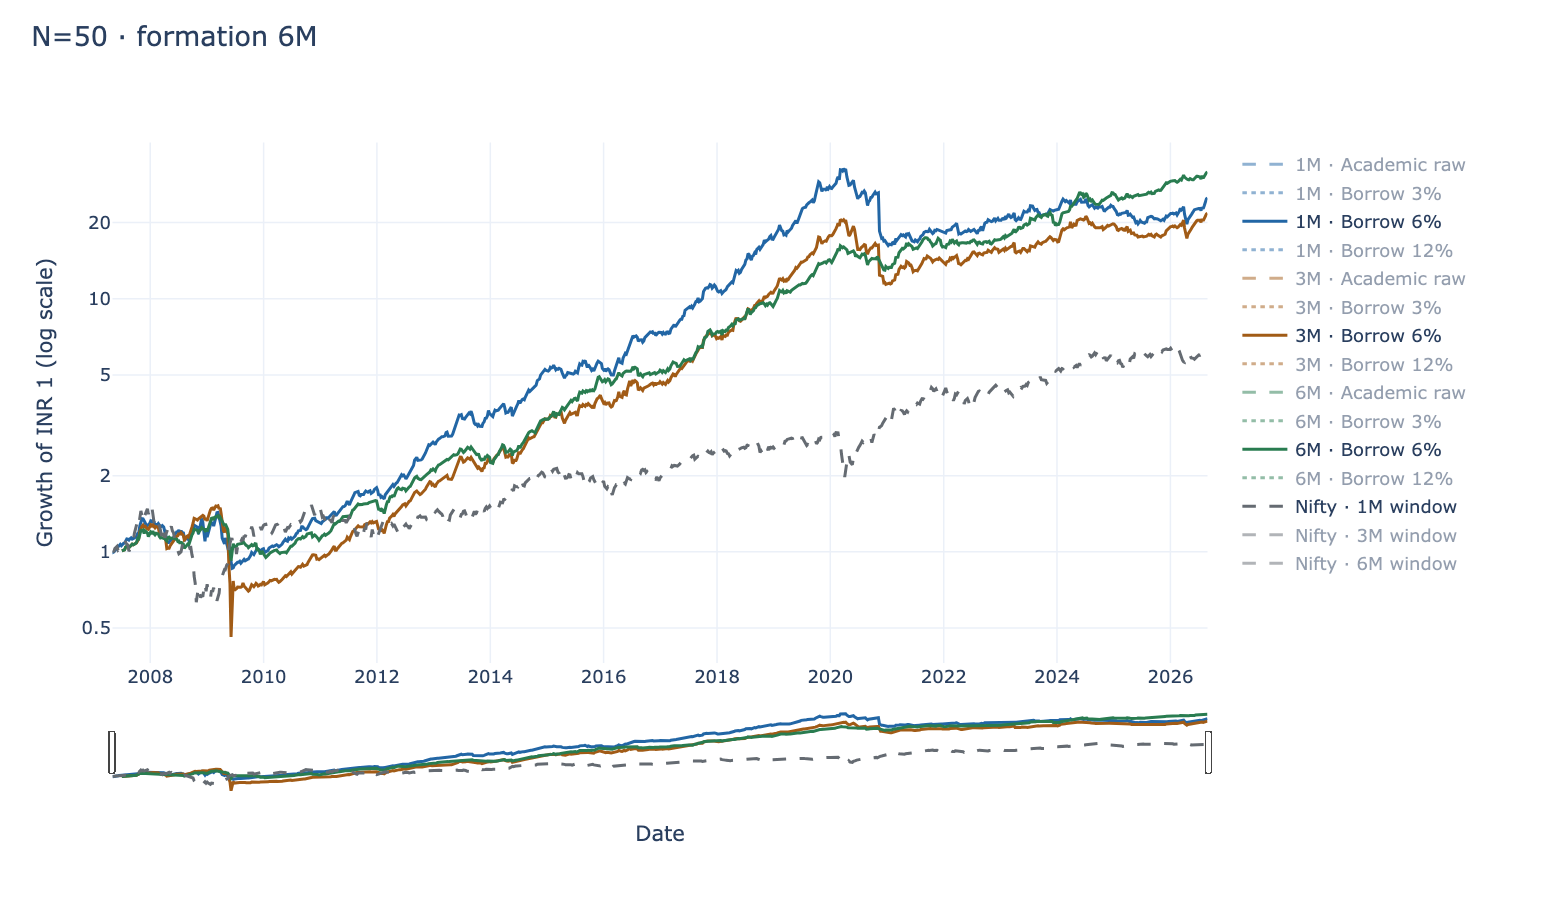

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,23.4%,1.075,-47.6%,7.1%
1M,Borrow 3%,20.8%,0.919,-49.1%,7.3%
1M,Borrow 6%,18.1%,0.759,-50.6%,7.5%
1M,Borrow 12%,12.7%,0.424,-58.7%,8.0%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,22.2%,0.926,-68.7%,6.6%
3M,Borrow 3%,19.8%,0.796,-69.2%,6.8%
3M,Borrow 6%,17.4%,0.663,-69.7%,7.1%
3M,Borrow 12%,12.6%,0.391,-70.6%,7.6%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,13.3%,85.9%,1564
1M,Borrow 3%,13.5%,86.9%,1580
1M,Borrow 6%,13.8%,87.9%,1580
1M,Borrow 12%,14.3%,89.8%,1580
3M,Academic raw,14.0%,86.0%,888
3M,Borrow 3%,14.2%,87.2%,947
3M,Borrow 6%,14.5%,88.8%,1031
3M,Borrow 12%,15.0%,91.0%,1600
6M,Academic raw,7.1%,81.6%,507
6M,Borrow 3%,7.2%,83.0%,533


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2020-04-08,2020-08-31,Not recovered,1580,2333,-36.4%
3M,2007-11-05,2009-06-05,2012-03-05,1067,1581,-69.9%
6M,2007-11-15,2008-08-11,2010-08-11,669,999,-30.3%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean long exposure,Mean short exposure,Borrow fees (INR)
1M,12,75.2%,98.9%,"227,451,415.23"
1M,24,67.5%,83.4%,"286,892,440.76"
1M,50,64.5%,75.4%,"110,969,515.75"
3M,12,64.5%,79.1%,"140,958,702.01"
3M,24,62.0%,71.6%,"177,721,635.72"
3M,50,61.2%,68.8%,"69,967,605.22"
6M,12,59.3%,61.0%,"88,555,864.30"
6M,24,56.0%,56.7%,"106,728,543.74"
6M,50,56.3%,56.6%,"64,159,673.48"


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

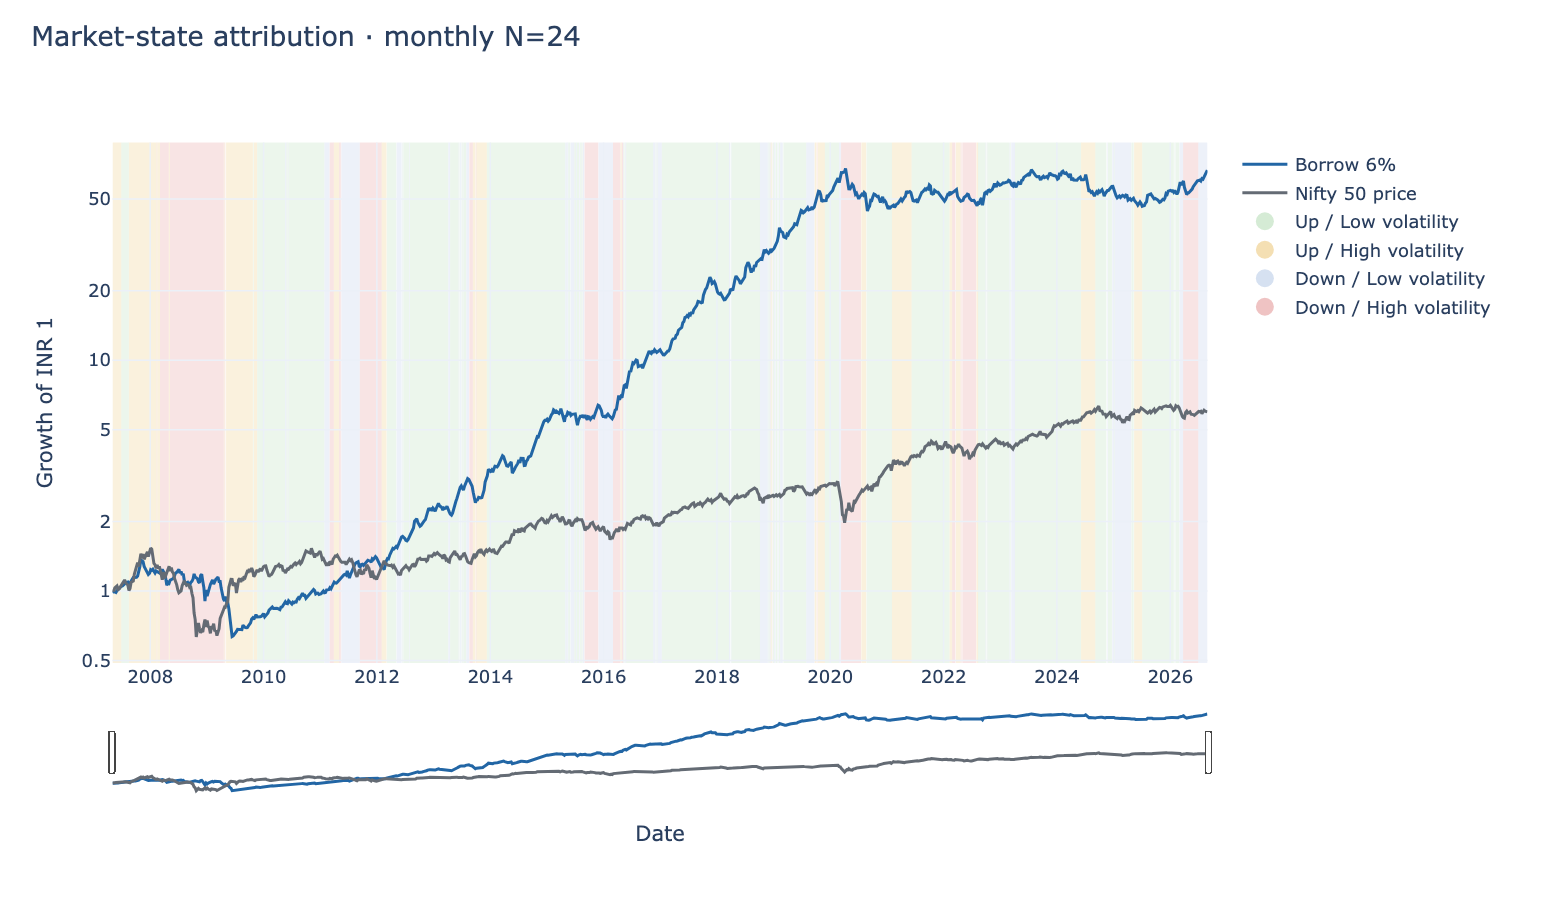

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.01%,1.21%,53.88%
Down / Low volatility,609,0.10%,1.01%,55.17%
Up / High volatility,720,0.00%,1.29%,52.92%
Up / Low volatility,2694,0.15%,1.01%,58.28%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,6312
1M,24,2007-05-03,2026-08-03,232,11247
1M,50,2007-05-03,2026-08-03,232,19934
3M,12,2007-07-02,2026-07-01,77,1806
3M,24,2007-07-02,2026-07-01,77,3411
3M,50,2007-07-02,2026-07-01,77,6139
6M,12,2007-07-02,2026-07-01,39,892
6M,24,2007-07-02,2026-07-01,39,1601
6M,50,2007-07-02,2026-07-01,39,3026


## Findings

In [16]:
research.conclusion()